# Cart-pole trajectory optimization with CasADi + FATROP

The notebook builds two NLPs in the variable and constraint order expected by FATROP's manual OCP interface.  The comparison is only about the transcription:

$$
\text{RK4 direct transcription}
\qquad \text{vs.}\qquad
\text{midpoint direct collocation}.
$$

In [1]:
# Cell 1 — imports and documentation links used while writing this notebook.
# CasADi docs: https://web.casadi.org/docs/
# CasADi Python API: https://web.casadi.org/python-api/
# CasADi nlpsol / FATROP plugin options: https://web.casadi.org/api/html/d4/d89/group__nlpsol.html
# FATROP documentation: https://meco-group.github.io/fatrop/
# FATROP paper: https://arxiv.org/abs/2303.16746

from dataclasses import dataclass
from pathlib import Path
from typing import Callable
import time

import casadi as ca
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Cell 2 — parameters, solver configuration, and NLP container.

@dataclass
class Param:
    mc: float = 10.0
    mp: float = 2.0
    l: float = 0.5
    g: float = 9.8
    b: float = 1.0
    d: float = 0.15
    a1: float = -0.1
    a2: float = -0.1
    b1: float = 0.3
    b2: float = 0.3


@dataclass
class Config:
    N: int = 500
    T: float = 5.0
    umax: float = 120.0
    x_limit: float = 4.0
    theta_limit: float = 2.5 * np.pi
    vel_limit: float = 60.0
    tol: float = 1e-7
    print_level: int = 0
    out_dir: str = "cartpole_fatrop_results"

    # theta = 0 is hanging, theta = pi is upright.
    x_init: tuple[float, float, float, float] = (0.0, 0.0, 0.0, 0.0)
    x_goal: tuple[float, float, float, float] = (0.0, np.pi, 0.0, 0.0)


@dataclass
class NLPData:
    name: str
    nlp: dict
    x0: list[float]
    lbx: list[float]
    ubx: list[float]
    lbg: list[float]
    ubg: list[float]
    equality: list[bool]
    nx_blocks: list[int]
    nu_blocks: list[int]
    ng_blocks: list[int]
    unpack: Callable[[np.ndarray], dict[str, np.ndarray]]
    build_time: float


The continuous-time model used by both NLPs is

$$
\dot x=f(x,u),\qquad
x=\begin{bmatrix}p&\theta&\dot p&\dot\theta\end{bmatrix}^{\mathsf T},\qquad u\in\mathbb R .
$$

The solver never sees this as a differential equation directly.  It only sees algebraic equality constraints produced by a transcription.

In [3]:
# Cell 3 — cart-pole dynamics translated from the MATLAB function.

def make_cartpole_dynamics(param: Param) -> ca.Function:
    x = ca.MX.sym("x", 4)
    u = ca.MX.sym("u", 1)

    mc = param.mc
    mp = param.mp
    l = param.l
    g = param.g
    b = param.b
    d = param.d

    x2 = x[1]
    x3 = x[2]
    x4 = x[3]

    s = ca.sin(x2)
    c = ca.cos(x2)
    den = mc + mp * s**2

    xdot1 = x3
    xdot2 = x4
    xdot3 = (u[0] - b * x3 + d * x4 * c / l + mp * s * (l * x4**2 + g * c)) / den
    xdot4 = (
        -u[0] * c
        + b * x3 * c
        - d * (mc + mp) * x4 / (mp * l)
        - mp * l * x4**2 * c * s
        - (mc + mp) * g * s / (mp * l)
    ) / (l * den)

    xdot = ca.vertcat(xdot1, xdot2, xdot3, xdot4)
    return ca.Function("cartpole_f", [x, u], [xdot]).expand()


def as_u(u_scalar_or_vec: ca.MX) -> ca.MX:
    return ca.reshape(u_scalar_or_vec, 1, 1)


In [4]:
# Cell 4 — RK4 direct transcription and Hermite-Simpson midpoint collocation formulas.

def rk4_step(f: ca.Function, x: ca.MX, u: ca.MX, h: float) -> ca.MX:
    # Direct transcription constraint later uses x_{k+1} - Phi_h^RK4(x_k, u_k) = 0.
    # The input is piecewise constant over [t_k, t_{k+1}].
    k1 = f(x, as_u(u))
    k2 = f(x + 0.5 * h * k1, as_u(u))
    k3 = f(x + 0.5 * h * k2, as_u(u))
    k4 = f(x + h * k3, as_u(u))
    return x + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


def midpoint_quantities(
    f: ca.Function,
    xk: ca.MX,
    uk: ca.MX,
    xkp1: ca.MX,
    ukp1: ca.MX,
    h: float,
) -> tuple[ca.MX, ca.MX, ca.MX, ca.MX]:
    # midpoint direct collocation / Hermite-Simpson:
    #
    # x_c    = 1/2 (x_k + x_{k+1}) + h/8 (f_k - f_{k+1})
    # u_c    = 1/2 (u_k + u_{k+1})
    # xdot_c = -3/(2h)(x_k - x_{k+1}) - 1/4(f_k + f_{k+1})
    # defect = xdot_c - f(x_c, u_c)
    fk = f(xk, as_u(uk))
    fkp1 = f(xkp1, as_u(ukp1))
    xc = 0.5 * (xk + xkp1) + (h / 8.0) * (fk - fkp1)
    uc = 0.5 * (uk + ukp1)
    xdot_c = -(3.0 / (2.0 * h)) * (xk - xkp1) - 0.25 * (fk + fkp1)
    defect = xdot_c - f(xc, as_u(uc))
    return defect, xc, uc, xdot_c


In [5]:
# Cell 5 — cost, bounds, and smooth initial guess.

def stage_cost(x: ca.MX, u: ca.MX, cfg: Config) -> ca.MX:
    p = x[0]
    pdot = x[2]
    thdot = x[3]
    return 1e-2 * p**2 + 1e-4 * pdot**2 + 1e-4 * thdot**2 + 1e-3 * (u / cfg.umax) ** 2


def smoothstep5(tau: float) -> tuple[float, float]:
    s = 10.0 * tau**3 - 15.0 * tau**4 + 6.0 * tau**5
    ds = 30.0 * tau**2 - 60.0 * tau**3 + 30.0 * tau**4
    return s, ds


def state_initial_guess(k: int, cfg: Config) -> np.ndarray:
    tau = k / cfg.N
    s, ds_dtau = smoothstep5(tau)

    theta = np.pi * s
    theta_dot = np.pi * ds_dtau / cfg.T

    A = 0.5
    envelope = (tau * (1.0 - tau)) ** 2
    denv = 2.0 * tau * (1.0 - tau) * (1.0 - 2.0 * tau)
    p = A * np.sin(2.0 * np.pi * tau) * envelope
    pdot = A * (
        2.0 * np.pi * np.cos(2.0 * np.pi * tau) * envelope
        + np.sin(2.0 * np.pi * tau) * denv
    ) / cfg.T

    xg = np.array([p, theta, pdot, theta_dot], dtype=float)
    if k == 0:
        xg = np.array(cfg.x_init, dtype=float)
    elif k == cfg.N:
        xg = np.array(cfg.x_goal, dtype=float)
    return xg


def x_bounds(cfg: Config) -> tuple[list[float], list[float]]:
    lb = [-cfg.x_limit, -cfg.theta_limit, -cfg.vel_limit, -cfg.vel_limit]
    ub = [cfg.x_limit, cfg.theta_limit, cfg.vel_limit, cfg.vel_limit]
    return lb, ub


For RK4 direct transcription, FATROP sees stage variables ordered as

$$
w_{\mathrm{RK4}}
=
\begin{bmatrix}
x_0,u_0,x_1,u_1,\ldots,x_{N-1},u_{N-1},x_N
\end{bmatrix}.
$$

The dynamic equality at interval $k$ is

$$
g_k^{\mathrm{RK4}}
=
x_{k+1}-\Phi_h^{\mathrm{RK4}}(x_k,u_k)=0.
$$

Locally, the Jacobian block seen by the solver is

$$
\frac{\partial g_k^{\mathrm{RK4}}}{\partial(x_k,u_k,x_{k+1})}
=
\begin{bmatrix}
-\Phi_x & -\Phi_u & I_4
\end{bmatrix}.
$$

So the global constraint Jacobian has the banded form

$$
\begin{bmatrix}
-\Phi_{x,0} & -\Phi_{u,0} & I_4          &             &        \\
             &             & -\Phi_{x,1} & -\Phi_{u,1} & I_4    \\
             &             &             & \ddots      & \ddots \\
             &             &             &             & -\Phi_{x,N-1}\; -\Phi_{u,N-1}\; I_4
\end{bmatrix}.
$$

In [6]:
# Cell 6 — build RK4 direct-transcription NLP in CasADi's FATROP manual OCP order.
# FATROP manual order:
#   variables:   x0, u0, x1, u1, ..., x_{N-1}, u_{N-1}, x_N
#   constraints: gap0, path0, gap1, path1, ..., gap_{N-1}, path_{N-1}, path_N
# In CasADi's FATROP plugin, structure_detection="manual" uses N, nx, nu, ng.

def build_rk4_nlp(f: ca.Function, cfg: Config) -> NLPData:
    t0 = time.perf_counter()
    N = cfg.N
    h = cfg.T / cfg.N
    x_lb, x_ub = x_bounds(cfg)

    X: list[ca.MX] = []
    U: list[ca.MX] = []
    w: list[ca.MX] = []
    lbx: list[float] = []
    ubx: list[float] = []
    w0: list[float] = []

    for k in range(N + 1):
        Xk = ca.MX.sym(f"X_{k}", 4)
        X.append(Xk)
        w.append(Xk)
        lbx += x_lb
        ubx += x_ub
        w0 += list(state_initial_guess(k, cfg))

        if k < N:
            Uk = ca.MX.sym(f"U_{k}", 1)
            U.append(Uk)
            w.append(Uk)
            lbx += [-cfg.umax]
            ubx += [cfg.umax]
            w0 += [0.0]

    g: list[ca.MX] = []
    lbg: list[float] = []
    ubg: list[float] = []
    equality: list[bool] = []
    ng_blocks = [0 for _ in range(N + 1)]
    J = 0

    for k in range(N + 1):
        if k < N:
            dyn = X[k + 1] - rk4_step(f, X[k], U[k], h)
            g.append(dyn)
            lbg += [0.0] * 4
            ubg += [0.0] * 4
            equality += [True] * 4
            J += h * stage_cost(X[k], U[k], cfg)

        path_constraints: list[ca.MX] = []
        if k == 0:
            path_constraints.append(X[k] - ca.DM(cfg.x_init))
        if k == N:
            path_constraints.append(X[k] - ca.DM(cfg.x_goal))

        if path_constraints:
            path = ca.vertcat(*path_constraints)
            g.append(path)
            n_path = int(path.numel())
            ng_blocks[k] += n_path
            lbg += [0.0] * n_path
            ubg += [0.0] * n_path
            equality += [True] * n_path

    nlp = {"x": ca.vertcat(*w), "f": J, "g": ca.vertcat(*g)}

    def unpack(wsol: np.ndarray) -> dict[str, np.ndarray]:
        X_sol = np.zeros((N + 1, 4))
        U_sol = np.zeros((N, 1))
        idx = 0
        for kk in range(N + 1):
            X_sol[kk, :] = wsol[idx : idx + 4]
            idx += 4
            if kk < N:
                U_sol[kk, 0] = wsol[idx]
                idx += 1
        return {"t": np.linspace(0.0, cfg.T, N + 1), "X": X_sol, "U_interval": U_sol}

    return NLPData(
        name="rk4_direct_transcription",
        nlp=nlp,
        x0=w0,
        lbx=lbx,
        ubx=ubx,
        lbg=lbg,
        ubg=ubg,
        equality=equality,
        nx_blocks=[4 for _ in range(N + 1)],
        nu_blocks=[1 for _ in range(N)] + [0],
        ng_blocks=ng_blocks,
        unpack=unpack,
        build_time=time.perf_counter() - t0,
    )


For midpoint collocation, the raw Hermite-Simpson defect depends on both endpoint controls:

$$
g_k^{\mathrm{col}}
=
\dot x_{c,k}-f(x_{c,k},u_{c,k})=0,
$$

$$
x_{c,k}
=
\frac12(x_k+x_{k+1})+\frac h8(f_k-f_{k+1}),
\qquad
u_{c,k}
=
\frac12(u_k+u_{k+1}).
$$

To keep the FATROP dynamic block in gap-closing form, the notebook lifts the variables:

$$
y_k=\begin{bmatrix}x_k\\u_k\end{bmatrix}\in\mathbb R^5,
\qquad
v_k=\begin{bmatrix}\bar x_{k+1}\\\bar u_{k+1}\end{bmatrix}\in\mathbb R^5.
$$

FATROP sees

$$
\underbrace{y_{k+1}-v_k=0}_{\text{dynamic block}},
\qquad
\underbrace{\dot x_{c,k}-f(x_{c,k},u_{c,k})=0}_{\text{path equality}},
$$

with local Jacobian structure

$$
\frac{\partial}{\partial(y_k,v_k,y_{k+1})}
\begin{bmatrix}
y_{k+1}-v_k\\
g_k^{\mathrm{col}}(y_k,v_k)
\end{bmatrix}
=
\begin{bmatrix}
0_{5\times5} & -I_5 & I_5\\
C_k          & D_k  & 0_{4\times5}
\end{bmatrix}.
$$

This is the key reason the collocation NLP is written in lifted form.

In [7]:
# Cell 7 — build midpoint direct-collocation NLP with lifted FATROP structure.
# A raw Hermite-Simpson defect depends on x_k, u_k, x_{k+1}, u_{k+1}.
# FATROP's manual dynamic block wants a gap with identity dependence on the next state block.
# Therefore use:
#   y_k = [x_k; u_k]                         nx = 5
#   v_k = [x_{k+1}^{copy}; u_{k+1}^{copy}]   nu = 5
#   dynamic gap: y_{k+1} - v_k = 0
#   path equality: Hermite-Simpson defect(y_k, v_k) = 0

def build_midpoint_collocation_nlp(f: ca.Function, cfg: Config) -> NLPData:
    t0 = time.perf_counter()
    N = cfg.N
    h = cfg.T / cfg.N

    x_lb, x_ub = x_bounds(cfg)
    y_lb = x_lb + [-cfg.umax]
    y_ub = x_ub + [cfg.umax]
    v_lb = x_lb + [-cfg.umax]
    v_ub = x_ub + [cfg.umax]

    Y: list[ca.MX] = []
    V: list[ca.MX] = []
    w: list[ca.MX] = []
    lbx: list[float] = []
    ubx: list[float] = []
    w0: list[float] = []

    for k in range(N + 1):
        Yk = ca.MX.sym(f"Y_{k}", 5)
        Y.append(Yk)
        w.append(Yk)
        lbx += y_lb
        ubx += y_ub
        w0 += list(state_initial_guess(k, cfg)) + [0.0]

        if k < N:
            Vk = ca.MX.sym(f"V_{k}", 5)
            V.append(Vk)
            w.append(Vk)
            lbx += v_lb
            ubx += v_ub
            w0 += list(state_initial_guess(k + 1, cfg)) + [0.0]

    g: list[ca.MX] = []
    lbg: list[float] = []
    ubg: list[float] = []
    equality: list[bool] = []
    ng_blocks = [0 for _ in range(N + 1)]
    J = 0

    for k in range(N + 1):
        if k < N:
            dyn = Y[k + 1] - V[k]
            g.append(dyn)
            lbg += [0.0] * 5
            ubg += [0.0] * 5
            equality += [True] * 5

            xk = Y[k][0:4]
            uk = Y[k][4]
            xkp1 = V[k][0:4]
            ukp1 = V[k][4]

            defect, xc, uc, _ = midpoint_quantities(f, xk, uk, xkp1, ukp1, h)
            g.append(defect)
            lbg += [0.0] * 4
            ubg += [0.0] * 4
            equality += [True] * 4
            ng_blocks[k] += 4

            J += (h / 6.0) * (
                stage_cost(xk, uk, cfg)
                + 4.0 * stage_cost(xc, uc, cfg)
                + stage_cost(xkp1, ukp1, cfg)
            )

        path_constraints: list[ca.MX] = []
        if k == 0:
            path_constraints.append(Y[k][0:4] - ca.DM(cfg.x_init))
        if k == N:
            path_constraints.append(Y[k][0:4] - ca.DM(cfg.x_goal))

        if path_constraints:
            path = ca.vertcat(*path_constraints)
            g.append(path)
            n_path = int(path.numel())
            ng_blocks[k] += n_path
            lbg += [0.0] * n_path
            ubg += [0.0] * n_path
            equality += [True] * n_path

    nlp = {"x": ca.vertcat(*w), "f": J, "g": ca.vertcat(*g)}

    def unpack(wsol: np.ndarray) -> dict[str, np.ndarray]:
        Y_sol = np.zeros((N + 1, 5))
        V_sol = np.zeros((N, 5))
        idx = 0
        for kk in range(N + 1):
            Y_sol[kk, :] = wsol[idx : idx + 5]
            idx += 5
            if kk < N:
                V_sol[kk, :] = wsol[idx : idx + 5]
                idx += 5
        return {
            "t": np.linspace(0.0, cfg.T, N + 1),
            "X": Y_sol[:, 0:4],
            "U_knots": Y_sol[:, 4:5],
            "endpoint_copy": V_sol,
        }

    return NLPData(
        name="midpoint_direct_collocation",
        nlp=nlp,
        x0=w0,
        lbx=lbx,
        ubx=ubx,
        lbg=lbg,
        ubg=ubg,
        equality=equality,
        nx_blocks=[5 for _ in range(N + 1)],
        nu_blocks=[5 for _ in range(N)] + [0],
        ng_blocks=ng_blocks,
        unpack=unpack,
        build_time=time.perf_counter() - t0,
    )


Both NLPs are passed to CasADi's `nlpsol(..., "fatrop", ...)` with manual OCP metadata:

$$
N,\qquad
\{n_{x,k}\}_{k=0}^N,\qquad
\{n_{u,k}\}_{k=0}^N,\qquad
\{n_{g,k}\}_{k=0}^N.
$$

The code keeps the benchmark printout for build time, solve time, objective, solver status, iteration count, and first knot points. CSV export is commented out, and the figures are displayed inline in the notebook.

In [8]:
# Cell 8 — solve with CasADi + FATROP, plot trajectories inline, and print trajectory heads.

def solve_with_fatrop(data: NLPData, cfg: Config) -> tuple[dict[str, np.ndarray], dict]:
    # CasADi nlpsol creates the solver. The second argument selects the plugin.
    # With structure_detection="manual", FATROP uses the supplied block dimensions.
    opts = {
        "structure_detection": "manual",
        "N": cfg.N,
        "nx": data.nx_blocks,
        "nu": data.nu_blocks,
        "ng": data.ng_blocks,
        "equality": data.equality,
        "expand": True,
        "print_time": True,
        "fatrop": {"tol": cfg.tol, "print_level": cfg.print_level},
    }

    solver = ca.nlpsol(f"solver_{data.name}", "fatrop", data.nlp, opts)

    t0 = time.perf_counter()
    sol = solver(
        x0=ca.DM(data.x0),
        lbx=ca.DM(data.lbx),
        ubx=ca.DM(data.ubx),
        lbg=ca.DM(data.lbg),
        ubg=ca.DM(data.ubg),
    )
    solve_time = time.perf_counter() - t0

    wsol = np.array(sol["x"]).reshape(-1)
    traj = data.unpack(wsol)
    stats = solver.stats()

    stats_out = {
        "name": data.name,
        "build_time_sec": data.build_time,
        "solve_time_sec": solve_time,
        "objective": float(sol["f"]),
        "return_status": stats.get("return_status", "unknown"),
        "iter_count": stats.get("iter_count", stats.get("iter_count_total", "unknown")),
    }
    return traj, stats_out


def save_traj_csv(name: str, traj: dict[str, np.ndarray], cfg: Config) -> None:
    # CSV export is intentionally disabled for notebook use.
    #
    # out = Path(cfg.out_dir)
    # out.mkdir(parents=True, exist_ok=True)
    #
    # t = traj["t"].reshape(-1, 1)
    # X = traj["X"]
    #
    # if "U_interval" in traj:
    #     U_node = np.vstack([traj["U_interval"], traj["U_interval"][-1:]])
    # else:
    #     U_node = traj["U_knots"]
    #
    # arr = np.hstack([t, X, U_node])
    # header = "t,p,theta,pdot,thetadot,u"
    # np.savetxt(out / f"{name}.csv", arr, delimiter=",", header=header, comments="")
    pass


def make_plots(results: dict[str, dict[str, np.ndarray]], cfg: Config) -> None:
    labels = ["p", "theta", "pdot", "thetadot"]
    for i, label in enumerate(labels):
        plt.figure()
        for name, traj in results.items():
            plt.plot(traj["t"], traj["X"][:, i], label=name)
        plt.xlabel("t [s]")
        plt.ylabel(label)
        plt.legend()
        plt.tight_layout()
        plt.show()

    plt.figure()
    for name, traj in results.items():
        if "U_interval" in traj:
            plt.step(traj["t"][:-1], traj["U_interval"][:, 0], where="post", label=name)
        else:
            plt.plot(traj["t"], traj["U_knots"][:, 0], label=name)
    plt.xlabel("t [s]")
    plt.ylabel("u")
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_trajectory_head(name: str, traj: dict[str, np.ndarray], rows: int = 8) -> None:
    print(f"\n{name}: first {rows} knot points")
    print("        t            p        theta         pdot     thetadot            u")
    X = traj["X"]
    t = traj["t"]
    if "U_interval" in traj:
        U_node = np.vstack([traj["U_interval"], traj["U_interval"][-1:]])[:, 0]
    else:
        U_node = traj["U_knots"][:, 0]
    for k in range(min(rows, len(t))):
        print(
            f"{t[k]:9.4f} {X[k,0]:12.6f} {X[k,1]:12.6f} "
            f"{X[k,2]:12.6f} {X[k,3]:12.6f} {U_node[k]:12.6f}"
        )


Building NLPs...

Solving rk4_direct_transcription with CasADi + FATROP...
solver_rk4_direct_transcription  :   t_proc      (avg)   t_wall      (avg)    n_eval
                          nlp_f  |        0 (       0)   1.50ms (  9.98us)       150
                          nlp_g  |  10.00ms (181.82us)  13.36ms (242.89us)        55
                     nlp_grad_f  |   3.00ms ( 61.22us) 852.00us ( 17.39us)        49
                     nlp_hess_l  | 176.00ms (  3.74ms) 178.12ms (  3.79ms)        47
                      nlp_jac_g  |  50.00ms (  1.02ms)  47.69ms (973.33us)        49
                          total  | 303.00ms (303.00ms) 303.39ms (303.39ms)         1

rk4_direct_transcription: first 8 knot points
        t            p        theta         pdot     thetadot            u
   0.0000     0.000000     0.000000     0.000000     0.000000     6.061789
   0.0100     0.000030    -0.000061     0.006057    -0.012091     6.642026
   0.0200     0.000124    -0.000247     0.012681    -0.025

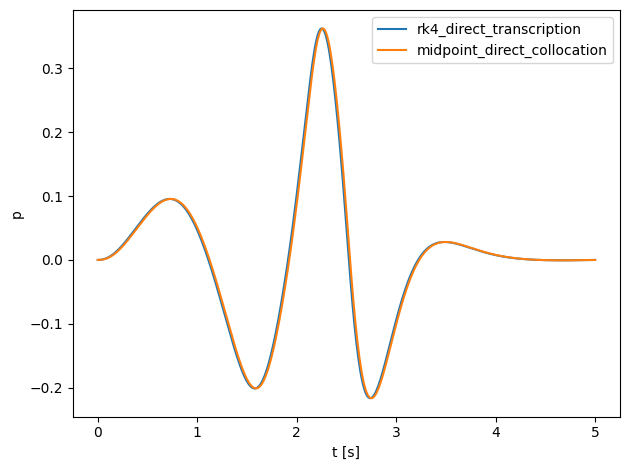

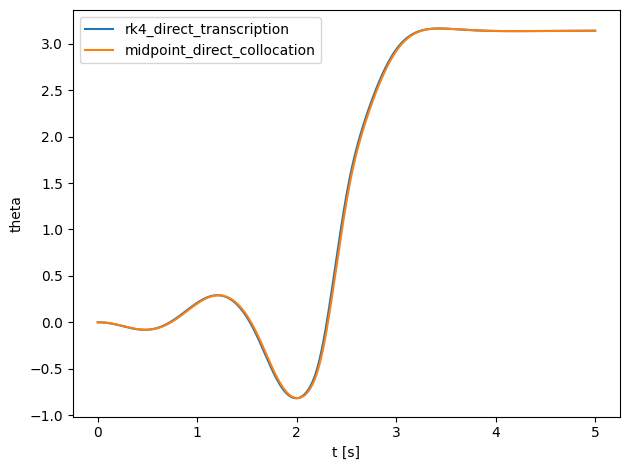

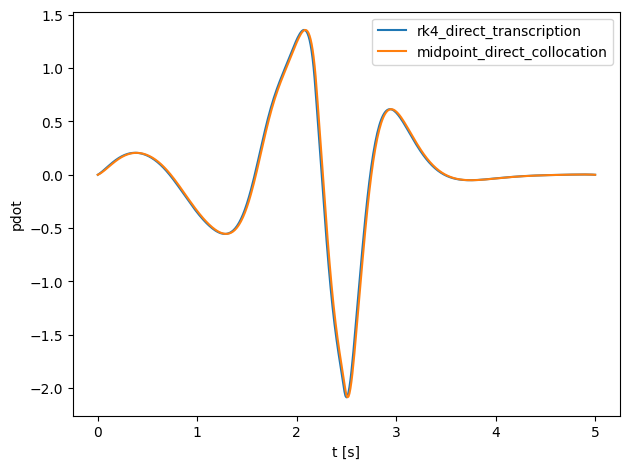

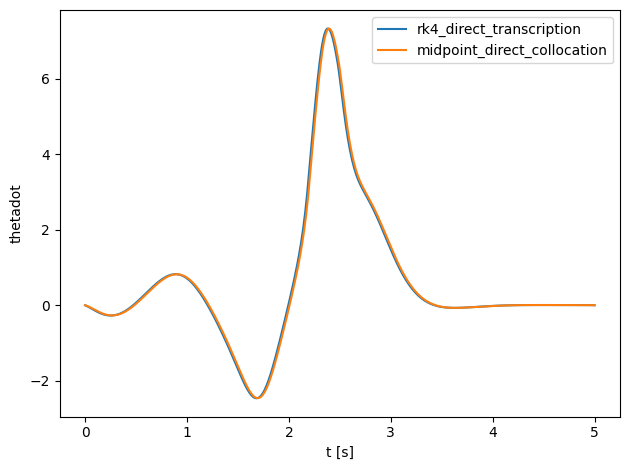

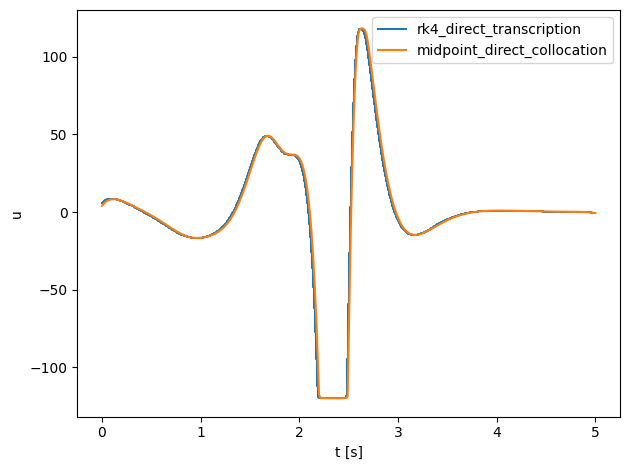


Timing / solver summary
method, build_time_sec, solve_time_sec, objective, status, iterations
rk4_direct_transcription, 0.169713, 0.304411, 3.552311891e-03, 0, 47
midpoint_direct_collocation, 0.302721, 1.202356, 3.551442041e-03, 0, 115


In [9]:
# Cell 9 — run the benchmark.

def main() -> None:
    cfg = Config()
    param = Param()
    f = make_cartpole_dynamics(param)

    print("Building NLPs...")
    rk4_data = build_rk4_nlp(f, cfg)
    col_data = build_midpoint_collocation_nlp(f, cfg)

    all_results: dict[str, dict[str, np.ndarray]] = {}
    all_stats: list[dict] = []

    for data in [rk4_data, col_data]:
        print(f"\nSolving {data.name} with CasADi + FATROP...")
        traj, stats = solve_with_fatrop(data, cfg)
        all_results[data.name] = traj
        all_stats.append(stats)
        # save_traj_csv(data.name, traj, cfg)
        print_trajectory_head(data.name, traj)

    make_plots(all_results, cfg)

    print("\nTiming / solver summary")
    print("method, build_time_sec, solve_time_sec, objective, status, iterations")
    for s in all_stats:
        print(
            f"{s['name']}, {s['build_time_sec']:.6f}, {s['solve_time_sec']:.6f}, "
            f"{s['objective']:.9e}, {s['return_status']}, {s['iter_count']}"
        )



main()
